# Problem 18: KNN Performance Using Different Distance Metrics

**Objective**: Compare KNN performance using different distance metrics and choose the best metric based on test accuracy and overall stability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import joblib

np.random.seed(42)

# Create a simple synthetic dataset: customer satisfaction classification
n_samples = 360
support_calls = np.random.randint(0, 12, n_samples)
usage_hours = np.random.uniform(0, 20, n_samples)
monthly_spend = np.random.uniform(10, 300, n_samples)
plan_tenure = np.random.uniform(0, 24, n_samples)

score = (0.25 * monthly_spend) + (1.5 * usage_hours) + (2.0 * plan_tenure) - (4.0 * support_calls)
score += np.random.normal(0, 8, n_samples)

satisfaction = np.zeros(n_samples, dtype=int)
satisfaction[score > 45] = 1
satisfaction[score > 70] = 2

df = pd.DataFrame({
    'support_calls': support_calls,
    'usage_hours': usage_hours,
    'monthly_spend': monthly_spend,
    'plan_tenure': plan_tenure,
    'satisfaction': satisfaction
})

csv_path = 'knn_distance_metrics.csv'
df.to_csv(csv_path, index=False)
print('Dataset created: {}'.format(csv_path))
print('Dataset shape: {}'.format(df.shape))
print(df['satisfaction'].value_counts().sort_index())

Dataset created: knn_distance_metrics.csv
Dataset shape: (360, 5)
satisfaction
0    133
1    111
2    116
Name: count, dtype: int64


In [2]:
df = pd.read_csv('knn_distance_metrics.csv')
print('Dataset Overview:')
print(df.head())
print('\nShape: {}'.format(df.shape))
print('\nInfo:')
print(df.info())
print('\nDescription:')
print(df.describe())

Dataset Overview:
   support_calls  usage_hours  monthly_spend  plan_tenure  satisfaction
0              6     0.486319      59.972763     1.127183             0
1              3    12.909446      65.763815     3.990801             0
2             10     3.542214      21.851899    17.712807             0
3              7    18.809172      58.991168     1.987168             0
4              4    19.078572      90.791198    14.475651             1

Shape: (360, 5)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   support_calls  360 non-null    int64  
 1   usage_hours    360 non-null    float64
 2   monthly_spend  360 non-null    float64
 3   plan_tenure    360 non-null    float64
 4   satisfaction   360 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 14.2 KB
None

Description:
       support_calls  usage_hours  monthly_spend  plan_

## Data Cleaning

Check missing values, duplicates, and class balance.

In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows: {}'.format(df.duplicated().sum()))
print('\nData types:')
print(df.dtypes)
print('\nClass distribution:')
print(df['satisfaction'].value_counts().sort_index())
df = df.drop_duplicates().reset_index(drop=True)
print('\nDataset shape after cleaning: {}'.format(df.shape))

Missing values:
support_calls    0
usage_hours      0
monthly_spend    0
plan_tenure      0
satisfaction     0
dtype: int64

Duplicate rows: 0

Data types:
support_calls      int64
usage_hours      float64
monthly_spend    float64
plan_tenure      float64
satisfaction       int64
dtype: object

Class distribution:
satisfaction
0    133
1    111
2    116
Name: count, dtype: int64

Dataset shape after cleaning: (360, 5)


## Exploratory Data Analysis (EDA)

Visualize how the features relate to customer satisfaction.

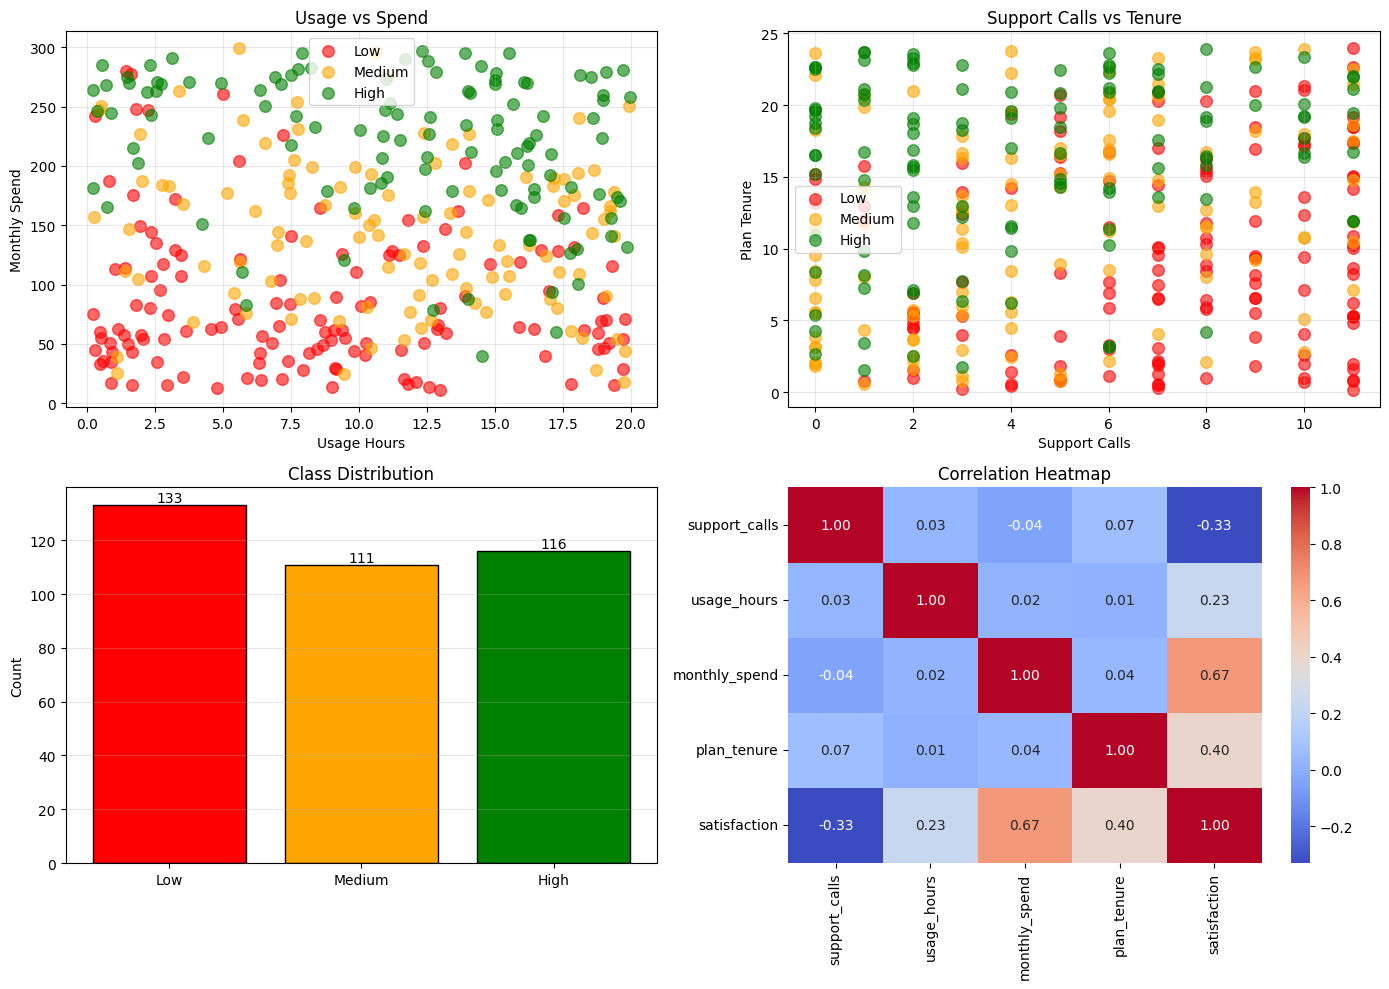

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
class_names = ['Low', 'Medium', 'High']
colors = ['red', 'orange', 'green']

for i, (label, color) in enumerate(zip([0, 1, 2], colors)):
    mask = df['satisfaction'] == label
    axes[0, 0].scatter(df[mask]['usage_hours'], df[mask]['monthly_spend'], label=class_names[i], alpha=0.6, color=color, s=70)
axes[0, 0].set_xlabel('Usage Hours')
axes[0, 0].set_ylabel('Monthly Spend')
axes[0, 0].set_title('Usage vs Spend')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for i, (label, color) in enumerate(zip([0, 1, 2], colors)):
    mask = df['satisfaction'] == label
    axes[0, 1].scatter(df[mask]['support_calls'], df[mask]['plan_tenure'], label=class_names[i], alpha=0.6, color=color, s=70)
axes[0, 1].set_xlabel('Support Calls')
axes[0, 1].set_ylabel('Plan Tenure')
axes[0, 1].set_title('Support Calls vs Tenure')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

counts = df['satisfaction'].value_counts().sort_index()
bars = axes[1, 0].bar(class_names, counts.values, color=colors, edgecolor='black')
axes[1, 0].set_title('Class Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, counts.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, value, str(value), ha='center', va='bottom')

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Feature Scaling

Scale the features because KNN depends on distance calculations.

In [5]:
X = df[['support_calls', 'usage_hours', 'monthly_spend', 'plan_tenure']].values
y = df['satisfaction'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling completed')
print('X shape: {}'.format(X_scaled.shape))
print('y shape: {}'.format(y.shape))
print('Class distribution: {}'.format(np.bincount(y.astype(int))))

Feature scaling completed
X shape: (360, 4)
y shape: (360,)
Class distribution: [133 111 116]


## Theory: Distance Metrics in KNN

KNN can use different distance metrics. The chosen metric changes which points are treated as nearest neighbors.

## Mathematical Representation

Euclidean distance:
$$d(x, z) = \sqrt{\sum_{i=1}^{n}(x_i - z_i)^2}$$

Manhattan distance:
$$d(x, z) = \sum_{i=1}^{n}|x_i - z_i|$$

Chebyshev distance:
$$d(x, z) = \max_i |x_i - z_i|$$

Minkowski distance:
$$d(x, z) = \left(\sum_{i=1}^{n}|x_i - z_i|^p\right)^{1/p}$$

## Workflow Diagram

Show the KNN distance metric comparison pipeline.

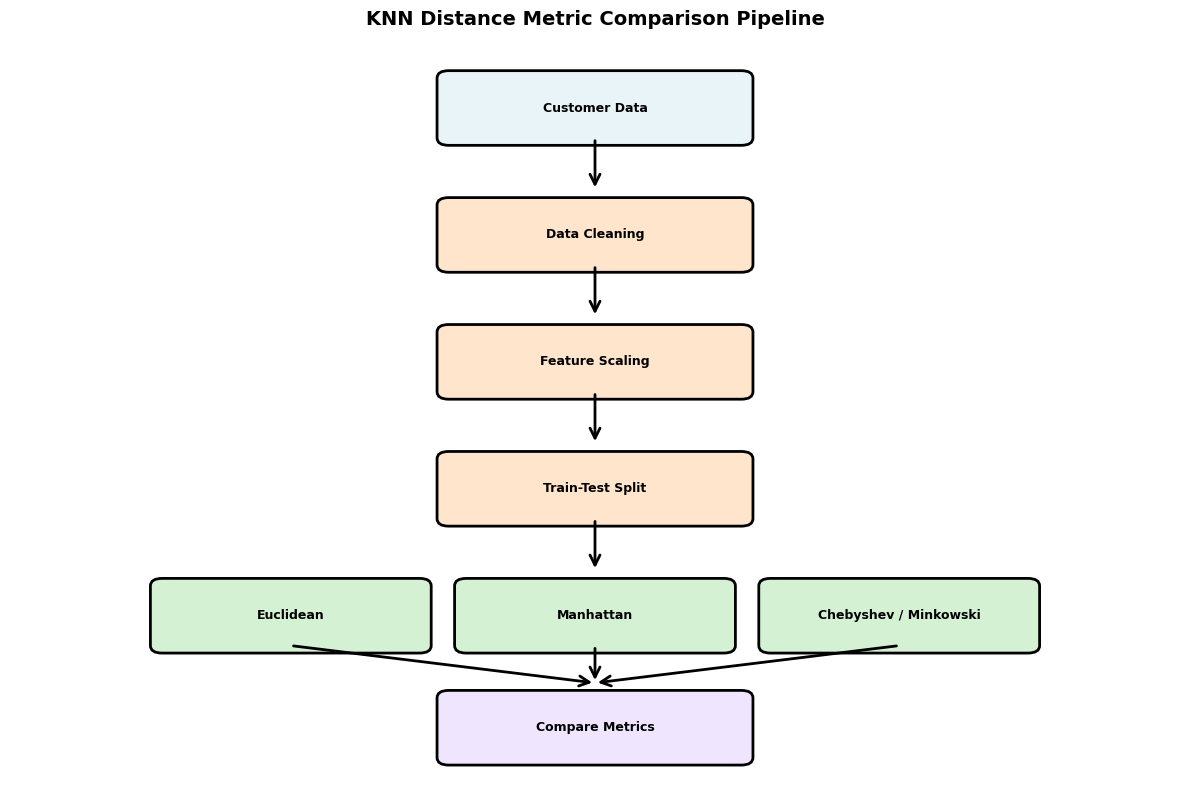

In [6]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

def add_box(x, y, w, h, text, color):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle='round,pad=0.1', edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold', wrap=True)

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=18, linewidth=2, color='black')
    ax.add_patch(arrow)

add_box(5, 9, 2.5, 0.8, 'Customer Data', '#E8F4F8')
add_arrow(5, 8.6, 5, 7.9)
add_box(5, 7.3, 2.5, 0.8, 'Data Cleaning', '#FFE5CC')
add_arrow(5, 6.9, 5, 6.2)
add_box(5, 5.6, 2.5, 0.8, 'Feature Scaling', '#FFE5CC')
add_arrow(5, 5.2, 5, 4.5)
add_box(5, 3.9, 2.5, 0.8, 'Train-Test Split', '#FFE5CC')
add_arrow(5, 3.5, 5, 2.8)
add_box(2.4, 2.2, 2.2, 0.8, 'Euclidean', '#D4F1D4')
add_box(5.0, 2.2, 2.2, 0.8, 'Manhattan', '#D4F1D4')
add_box(7.6, 2.2, 2.2, 0.8, 'Chebyshev / Minkowski', '#D4F1D4')
add_arrow(2.4, 1.8, 5, 1.3)
add_arrow(5.0, 1.8, 5, 1.3)
add_arrow(7.6, 1.8, 5, 1.3)
add_box(5, 0.7, 2.5, 0.8, 'Compare Metrics', '#F0E5FF')

plt.title('KNN Distance Metric Comparison Pipeline', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Pseudocode

1. Load and clean the dataset.
2. Scale the features.
3. Split the data into training and testing sets.
4. Train KNN models using different distance metrics.
5. Predict the test set and calculate metrics.
6. Compare accuracy, precision, recall, and F1 score.
7. Select the best metric and save the model.

## Train-Test Split

Create training and testing sets with stratification.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print('Training samples: {}'.format(X_train.shape[0]))
print('Testing samples: {}'.format(X_test.shape[0]))
print('Training class distribution: {}'.format(np.bincount(y_train.astype(int))))
print('Testing class distribution: {}'.format(np.bincount(y_test.astype(int))))

Training samples: 288
Testing samples: 72
Training class distribution: [106  89  93]
Testing class distribution: [27 22 23]


## Test Different Distance Metrics

Train KNN with Euclidean, Manhattan, Chebyshev, and Minkowski distance metrics.

In [8]:
metrics = {
    'Euclidean': {'metric': 'minkowski', 'p': 2},
    'Manhattan': {'metric': 'minkowski', 'p': 1},
    'Chebyshev': {'metric': 'chebyshev'},
    'Minkowski p=3': {'metric': 'minkowski', 'p': 3}
}

metric_models = {}
metric_results = {}

print('Testing different distance metrics...')
print('=' * 90)
print('{:<15} {:>10} {:>10} {:>10} {:>10} {:>10}'.format('Metric', 'Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1 Score'))
print('-' * 90)

for name, params in metrics.items():
    knn = KNeighborsClassifier(n_neighbors=5, **params)
    knn.fit(X_train, y_train)
    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted')
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')

    metric_models[name] = knn
    metric_results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Predictions': y_pred_test,
        'Confusion Matrix': confusion_matrix(y_test, y_pred_test)
    }

    print('{:<15} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}'.format(name, train_acc, test_acc, precision, recall, f1))

print('=' * 90)

Testing different distance metrics...
Metric           Train Acc   Test Acc  Precision     Recall   F1 Score
------------------------------------------------------------------------------------------
Euclidean           0.8611     0.7361     0.7455     0.7361     0.7379
Manhattan           0.8542     0.7222     0.7185     0.7222     0.7141
Chebyshev           0.8576     0.7361     0.7354     0.7361     0.7338
Minkowski p=3       0.8576     0.7500     0.7578     0.7500     0.7509


## Compare Distance Metrics

Find the best performing metric based on test accuracy.

In [9]:
best_metric = max(metric_results.items(), key=lambda item: item[1]['Test Accuracy'])[0]
best_test_accuracy = metric_results[best_metric]['Test Accuracy']

print('Best metric by test accuracy: {}'.format(best_metric))
print('Test accuracy: {:.4f}'.format(best_test_accuracy))

comparison_df = pd.DataFrame({
    'Metric': list(metric_results.keys()),
    'Train Accuracy': [metric_results[m]['Train Accuracy'] for m in metric_results],
    'Test Accuracy': [metric_results[m]['Test Accuracy'] for m in metric_results],
    'Precision': [metric_results[m]['Precision'] for m in metric_results],
    'Recall': [metric_results[m]['Recall'] for m in metric_results],
    'F1 Score': [metric_results[m]['F1 Score'] for m in metric_results]
})
print(comparison_df.to_string(index=False))

Best metric by test accuracy: Minkowski p=3
Test accuracy: 0.7500
       Metric  Train Accuracy  Test Accuracy  Precision   Recall  F1 Score
    Euclidean        0.861111       0.736111   0.745517 0.736111  0.737856
    Manhattan        0.854167       0.722222   0.718510 0.722222  0.714107
    Chebyshev        0.857639       0.736111   0.735443 0.736111  0.733777
Minkowski p=3        0.857639       0.750000   0.757804 0.750000  0.750894


## Visualization of Metric Comparison

Plot the performance of each distance metric.

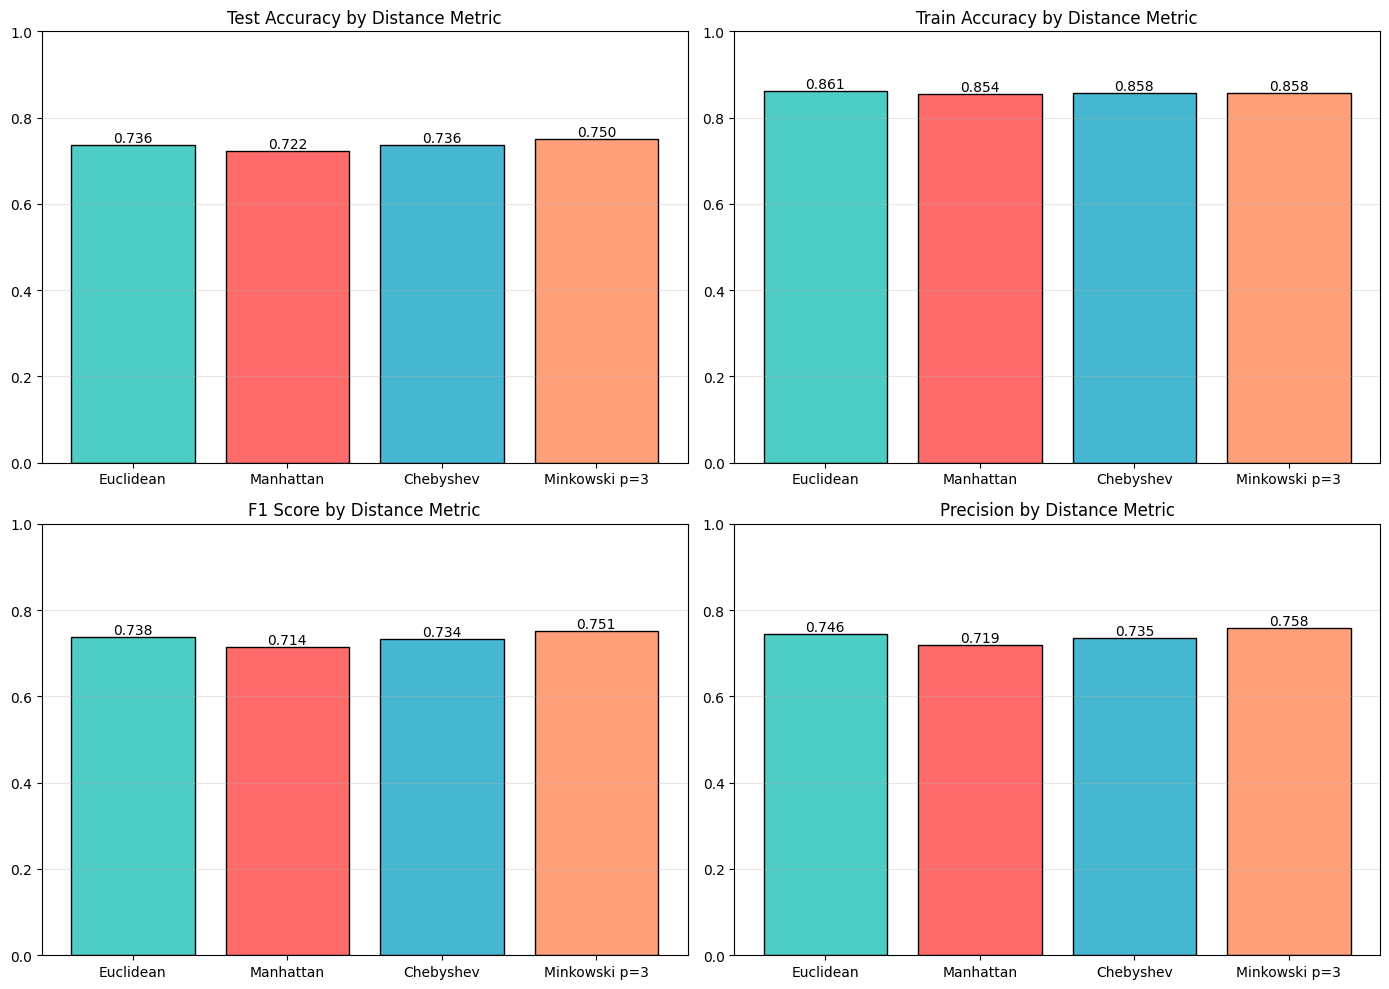

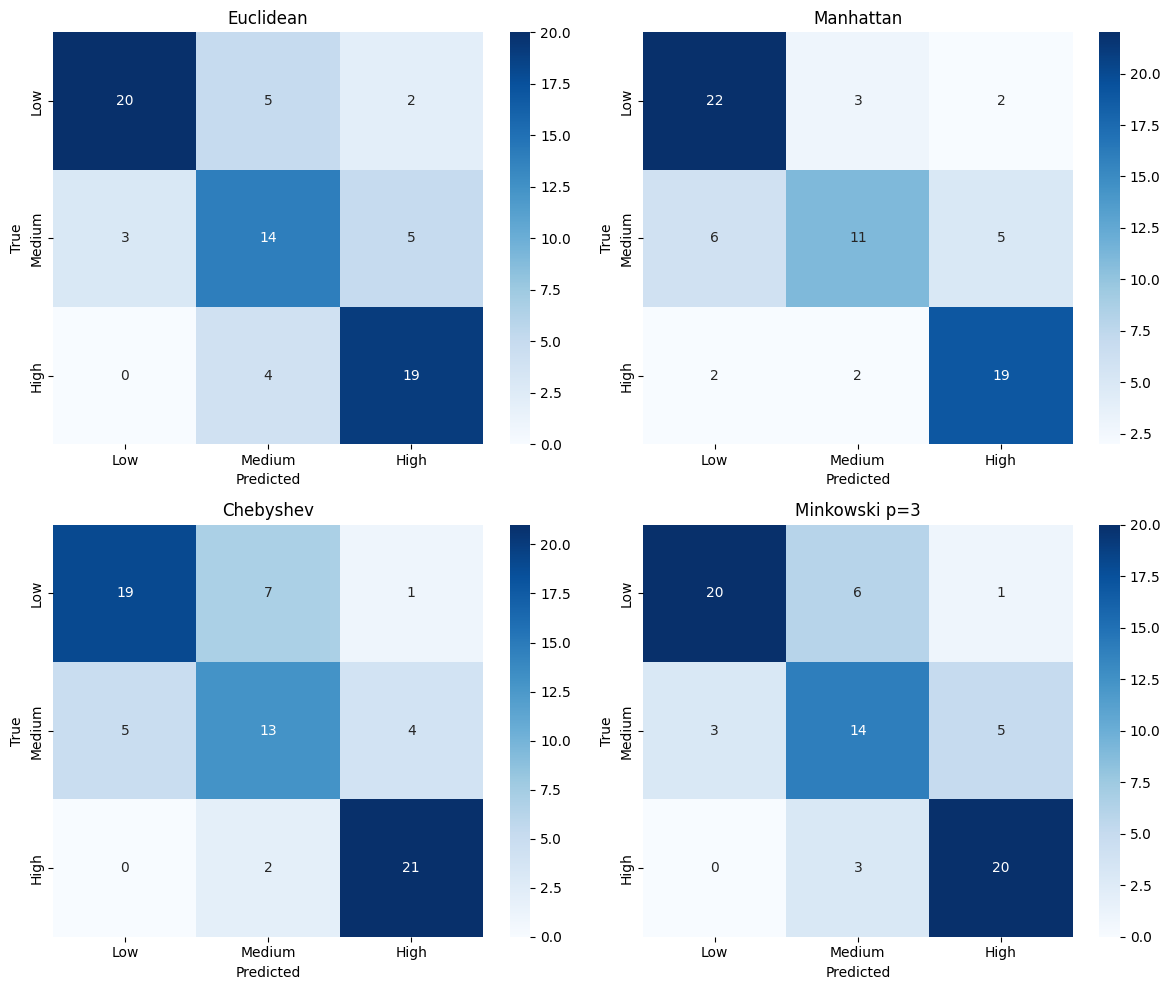

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_names = list(metric_results.keys())
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#FFA07A']

test_accs = [metric_results[m]['Test Accuracy'] for m in metric_names]
train_accs = [metric_results[m]['Train Accuracy'] for m in metric_names]
f1_scores = [metric_results[m]['F1 Score'] for m in metric_names]
precision_scores = [metric_results[m]['Precision'] for m in metric_names]

bars = axes[0, 0].bar(metric_names, test_accs, color=colors, edgecolor='black')
axes[0, 0].set_title('Test Accuracy by Distance Metric')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, test_accs):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, value, '{:.3f}'.format(value), ha='center', va='bottom')

bars = axes[0, 1].bar(metric_names, train_accs, color=colors, edgecolor='black')
axes[0, 1].set_title('Train Accuracy by Distance Metric')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, train_accs):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, value, '{:.3f}'.format(value), ha='center', va='bottom')

bars = axes[1, 0].bar(metric_names, f1_scores, color=colors, edgecolor='black')
axes[1, 0].set_title('F1 Score by Distance Metric')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, f1_scores):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, value, '{:.3f}'.format(value), ha='center', va='bottom')

bars = axes[1, 1].bar(metric_names, precision_scores, color=colors, edgecolor='black')
axes[1, 1].set_title('Precision by Distance Metric')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, precision_scores):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, value, '{:.3f}'.format(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
class_labels = ['Low', 'Medium', 'High']

for idx, metric_name in enumerate(metric_names):
    sns.heatmap(metric_results[metric_name]['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=class_labels, yticklabels=class_labels)
    axes[idx].set_title(metric_name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

## Model Persistence

Save the best distance metric model and scaler.

In [11]:
best_model = metric_models[best_metric]
joblib.dump(best_model, 'knn_best_distance_metric.joblib')
joblib.dump(scaler, 'scaler_knn_distance_metric.joblib')

print('✓ Best KNN model saved to: knn_best_distance_metric.joblib')
print('✓ Scaler saved to: scaler_knn_distance_metric.joblib')

new_data = np.array([
    [1, 14, 220, 18],
    [8, 2, 40, 1],
    [3, 9, 160, 12]
])
new_data_scaled = scaler.transform(new_data)
new_predictions = best_model.predict(new_data_scaled)
new_proba = best_model.predict_proba(new_data_scaled)

print('\nPredictions for new data:')
for i in range(len(new_data)):
    print('Input {}: {} -> Class {}, Confidence {:.2%}'.format(i + 1, new_data[i], int(new_predictions[i]), np.max(new_proba[i])))

print('\n✓ KNN distance metric comparison completed successfully!')

✓ Best KNN model saved to: knn_best_distance_metric.joblib
✓ Scaler saved to: scaler_knn_distance_metric.joblib

Predictions for new data:
Input 1: [  1  14 220  18] -> Class 2, Confidence 100.00%
Input 2: [ 8  2 40  1] -> Class 0, Confidence 100.00%
Input 3: [  3   9 160  12] -> Class 1, Confidence 80.00%

✓ KNN distance metric comparison completed successfully!
